# 실습 03. 규제 선형 회귀

## 데이터
- scikit-learn 제공 `load_diabetes()` 데이터셋
- target: 질병 진행 정도를 나타내는 연속값

## 불러온 데이터와 컬럼 정보

### Diabetes 데이터
- 데이터 출처: scikit-learn 제공 `load_diabetes()` 데이터셋
- 데이터 크기: 442행, 10개 feature + target
- 데이터 내용: 당뇨병 환자의 기본 신체 지표와 혈액 검사 지표를 이용해 1년 후 질병 진행 정도를 예측하는 회귀 예제 데이터
- target: 1년 후 질병 진행 정도를 나타내는 연속값
- 참고: scikit-learn의 diabetes feature는 이미 평균 중심화와 스케일 조정이 되어 있음

| 컬럼 | 의미 | 이번 실습 사용 |
|---|---|---|
| `age` | 나이 | 사용 feature |
| `sex` | 성별 | 사용 feature |
| `bmi` | 체질량지수 | 사용 feature |
| `bp` | 평균 혈압 | 사용 feature |
| `s1` | 총 혈청 콜레스테롤 | 사용 feature |
| `s2` | 저밀도 지단백 LDL | 사용 feature |
| `s3` | 고밀도 지단백 HDL | 사용 feature |
| `s4` | 총 콜레스테롤 / HDL 비율 | 사용 feature |
| `s5` | 혈청 중성지방 수치의 로그값으로 추정되는 지표 | 사용 feature |
| `s6` | 혈당 수치 | 사용 feature |
| `target` | 1년 후 질병 진행 정도 | target |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

raw = load_diabetes(as_frame=True)
X = raw.data.copy()
y = raw.target.copy()

feature_names = X.columns.tolist()

print(X.shape, y.shape)
X.head()


(442, 10) (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 문제 1. 데이터 분리

`load_diabetes()` 데이터셋을 학습용과 평가용으로 분리하세요.

### 요구사항
- `test_size=0.2`, `random_state=42` 사용
- 분리 결과 shape 출력

### 힌트
- 규제 모델 비교를 위해 모든 모델이 같은 train/test 데이터를 사용해야 함.

### 실행 결과

```text
X_train: (353, 10)
X_test: (89, 10)
y_train: (353,)
y_test: (89,)
```


In [2]:
# TODO: train_test_split()으로 데이터를 분리하세요.
# 조건: test_size=0.2, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TODO: 분리 결과 shape를 출력하세요.
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(353, 10) (89, 10) (353,) (89,)


## 문제 2. LinearRegression, Ridge, Lasso, ElasticNet 비교

스케일링과 모델을 `Pipeline`으로 묶고 네 가지 모델을 같은 방식으로 학습/평가하세요.

### 요구사항
- 비교 모델: `LinearRegression`, `Ridge(alpha=1.0)`, `Lasso(alpha=0.1)`, `ElasticNet(alpha=0.1, l1_ratio=0.5)`
- 각 모델의 `R2`, `MAE`, `RMSE`를 DataFrame으로 정리
- 규제 모델은 스케일링 영향을 크게 받으므로 `StandardScaler` 포함

### 힌트
- `Pipeline([('scaler', StandardScaler()), ('model', model)])` 형태를 사용함.

### 실행 결과

```text
model        R2        MAE       RMSE
3        ElasticNet  0.458970  42.873332  53.539343
2             Lasso  0.455541  42.805234  53.708698
1             Ridge  0.454147  42.811999  53.777454
0  LinearRegression  0.452603  42.794095  53.853446
```


In [5]:
# TODO: 비교할 모델 딕셔너리를 만드세요.
model = {'linear': LinearRegression(), "ridge": Ridge(alpha=1.0), "lasso": Lasso(alpha=0.1), "elastic":ElasticNet(alpha=0.1, l1_ratio=0.5)}

# TODO: 반복문으로 Pipeline 생성, 학습, 예측, 평가를 수행하세요.
model_score = []
for name, model in model.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(name, r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), root_mean_squared_error(y_test, y_pred))
    model_score.append([name, r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred), root_mean_squared_error(y_test, y_pred)])
# TODO: 결과를 DataFrame으로 정리하세요.
model_df = pd.DataFrame(model_score, columns=['model', 'R2', 'MAE', 'RMSE'])
model_df

linear 0.45260276297191904 42.79409467959996 53.85344583676595
ridge 0.45414652070698236 42.81199941834889 53.77745406534389
lasso 0.455541399027904 42.805234446768836 53.708698445737944
elastic 0.4589695819678379 42.87333224331687 53.539343060013046


,model,R2,MAE,RMSE
0,linear,0.452603,42.794095,53.853446
1,ridge,0.454147,42.811999,53.777454
2,lasso,0.455541,42.805234,53.708698
3,elastic,0.458970,42.873332,53.539343


## 문제 3. Ridge의 alpha 후보 비교

`alpha` 값을 바꿔가며 Ridge 모델의 평가 성능을 비교하세요.

### 요구사항
- 후보값: `[0.01, 0.1, 1, 10, 100]`
- 각 alpha별 `R2`, `RMSE`, 회귀계수 제곱합 출력
- 결과를 DataFrame으로 정리

### 힌트
- `alpha`가 커질수록 회귀계수 크기를 더 강하게 줄임.

### 실행 결과

```text
alpha        R2       RMSE  coef_square_sum
0    0.01  0.452625  53.852346      5109.907148
1    0.10  0.452818  53.842869      4930.049707
2    1.00  0.454147  53.777454      3709.887434
3   10.00  0.457211  53.626288      1851.406173
4  100.00  0.460524  53.462363      1175.312176
```


In [8]:
# TODO: alpha 후보 리스트를 만드세요.
alpha = [0.01, 0.1, 1, 10, 100]

# TODO: 각 alpha로 Ridge Pipeline을 학습하고 평가하세요.
score = []
for alpha in alpha:
    pipeline = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha))])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    score.append([alpha, r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred), sum(pipeline.named_steps['model'].coef_ ** 2)])
# TODO: alpha, R2, RMSE, 회귀계수 제곱합을 DataFrame으로 정리하세요.
ridge_df = pd.DataFrame(score, columns=['alpha', 'R2', 'RMSE', 'coef_square_sum'])
ridge_df

,alpha,R2,RMSE,coef_square_sum
0,0.01,0.452625,53.852346,5109.907148
1,0.10,0.452818,53.842869,4930.049707
2,1.00,0.454147,53.777454,3709.887434
3,10.00,0.457211,53.626288,1851.406173
4,100.00,0.460524,53.462363,1175.312176


## 문제 4. alpha별 RMSE 시각화

문제 3에서 만든 결과를 이용해 alpha별 RMSE 변화를 그래프로 그리세요.

### 요구사항
- x축은 `alpha`
- y축은 `RMSE`
- x축은 로그 스케일 사용

### 힌트
- alpha 후보가 0.01부터 100까지 넓게 퍼져 있으므로 로그 스케일이 보기 좋음.

### 실행 결과

![정답 실행 그래프](images/03_regularized_linear_regression_problem_4_fig1.png)


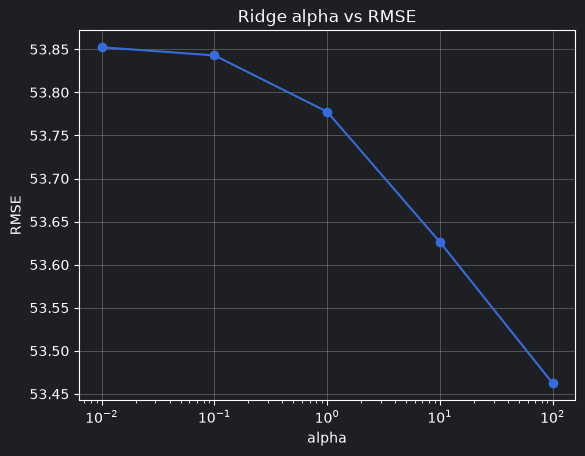

In [19]:
# TODO: ridge_alpha_df를 이용해 alpha별 RMSE 그래프를 그리세요.
plt.figure()
plt.plot(ridge_df['alpha'], ridge_df['RMSE'], marker='o', linestyle='-', label='RMSE')
plt.xscale('log')
plt.title("Ridge alpha vs RMSE")
plt.grid(True)
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.show()